# LiH: ZNE Baseline Comparison (Updated)

Two ZNE configurations + RF + MLP comparison.
Matches H₂ zne_comparison.ipynb structure.

## 1. Imports

In [2]:
import numpy as np
import json
import matplotlib.pyplot as plt
import joblib
import time
import torch
import torch.nn as nn

In [1]:
from qiskit.circuit.library import TwoLocal

In [3]:
from qiskit.quantum_info import SparsePauliOp, Pauli

In [4]:
from qiskit import transpile, QuantumCircuit
from qiskit_aer.noise import NoiseModel

In [5]:
from qiskit_aer.primitives import Estimator as AerEstimatorV1
from qiskit_ibm_runtime.fake_provider import FakeJakartaV2
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import StandardScaler

plt.rcParams.update({'font.size': 12, 'axes.titlesize': 14, 'axes.labelsize': 12,
                     'figure.dpi': 150})
print('All imports OK')

All imports OK


## 2. Gate Folding

In [6]:
def fold_cx_gates(circuit, fold_factor=3):
    assert fold_factor % 2 == 1, 'fold_factor must be odd'
    folded = QuantumCircuit(circuit.num_qubits)
    for inst in circuit.data:
        folded.append(inst)
        if inst.operation.name == 'cx':
            for _ in range(fold_factor - 1):
                folded.append(inst)
    return folded
print('Gate folding ready.')

Gate folding ready.


## 3. Load Data and Setup

In [7]:
ideal_data = np.load('lih_ideal_data.npy')
noisy_data = np.load('lih_noisy_data.npy')
theta_samples = np.load('lih_theta_samples.npy')

with open('lih_meta.json') as f:
    meta = json.load(f)

PAULI_LABELS = meta['pauli_labels']
PAULI_COEFFS = meta['hamiltonian_coeffs']
N_QUBITS = meta['n_qubits']
pauli_ops = [SparsePauliOp(label) for label in PAULI_LABELS]

ideal_test = ideal_data[1800:]
noisy_test = noisy_data[1800:]
theta_test = theta_samples[1800:]

ansatz = TwoLocal(num_qubits=N_QUBITS, rotation_blocks='ry',
                  entanglement_blocks='cx', entanglement='linear', reps=3)
transpiled_ansatz = transpile(ansatz, basis_gates=['rz', 'sx', 'cx', 'x'],
                              optimization_level=1)

backend = FakeJakartaV2()
noise_model = NoiseModel.from_backend(backend)
noisy_estimator = AerEstimatorV1()
noisy_estimator.set_options(noise_model=noise_model, shots=10000)

print(f'Test set: {len(theta_test)} θ values, {len(PAULI_LABELS)} observables')

Test set: 200 θ values, 62 observables


## 4. Run ZNE Circuits (3x and 5x)

In [8]:
N_TEST = len(theta_test)
N_OBS = len(pauli_ops)

noisy_3x = np.zeros((N_TEST, N_OBS))
noisy_5x = np.zeros((N_TEST, N_OBS))

t0 = time.time()
for i, theta in enumerate(theta_test):
    bound = transpiled_ansatz.assign_parameters(theta)

    folded_3x = fold_cx_gates(bound, fold_factor=3)
    job_3x = noisy_estimator.run([folded_3x] * N_OBS, pauli_ops)
    res_3x = job_3x.result()

    folded_5x = fold_cx_gates(bound, fold_factor=5)
    job_5x = noisy_estimator.run([folded_5x] * N_OBS, pauli_ops)
    res_5x = job_5x.result()

    for j in range(N_OBS):
        noisy_3x[i, j] = res_3x.values[j]
        noisy_5x[i, j] = res_5x.values[j]

    if (i + 1) % 25 == 0:
        elapsed = time.time() - t0
        eta = elapsed / (i + 1) * (N_TEST - i - 1)
        print(f'  {i+1}/{N_TEST} done ({elapsed/60:.1f} min, ~{eta/60:.0f} min left)')

print(f'Done in {(time.time() - t0)/60:.1f} minutes.')

  25/200 done (2.1 min, ~15 min left)
  50/200 done (4.3 min, ~13 min left)
  75/200 done (6.2 min, ~10 min left)
  100/200 done (8.1 min, ~8 min left)
  125/200 done (10.1 min, ~6 min left)
  150/200 done (12.0 min, ~4 min left)
  175/200 done (13.9 min, ~2 min left)
  200/200 done (15.7 min, ~0 min left)
Done in 15.7 minutes.


## 5. ZNE Extrapolation

In [9]:
zne_linear = (3 * noisy_test - noisy_3x) / 2
zne_quadratic = (15/8) * noisy_test + (-5/4) * noisy_3x + (3/8) * noisy_5x

print('Extrapolation computed.')

Extrapolation computed.


## 6. Load RF and MLP

In [10]:
rf = joblib.load('lih_rf_mlqem.joblib')

props = backend.properties()
qubit_noise = {}
for q in range(N_QUBITS):
    qubit_noise[q] = {
        'T1': props.qubit_property(q, 'T1')[0] * 1e6,
        'T2': props.qubit_property(q, 'T2')[0] * 1e6,
        'readout_error': props.qubit_property(q, 'readout_error')[0],
    }

SYMPLECTIC = {label: np.concatenate([Pauli(label).x.astype(int), Pauli(label).z.astype(int)])
              for label in PAULI_LABELS}
N_2Q = meta['n_2q_gates']
N_SX = meta['n_sx_gates']
ALL_OBS = list(range(1, len(PAULI_LABELS)))

def qubit_noise_features(symp):
    feats = []
    for q in range(N_QUBITS):
        active = float(symp[q] == 1 or symp[q + N_QUBITS] == 1)
        feats.extend([qubit_noise[q]['T1']*active, qubit_noise[q]['T2']*active,
                      qubit_noise[q]['readout_error']*active])
    return feats

rf_corrected = noisy_test.copy()
for obs_idx in ALL_OBS:
    label = PAULI_LABELS[obs_idx]
    symp = SYMPLECTIC[label]
    nf = qubit_noise_features(symp)
    N = len(noisy_test)
    feats = np.column_stack([noisy_test[:, obs_idx], np.tile(symp, (N,1)),
                             np.full((N,1), N_2Q), np.full((N,1), N_SX), np.tile(nf, (N,1))])
    rf_corrected[:, obs_idx] = rf.predict(feats)
print('RF corrections computed.')

# Train MLP
class MLP(torch.nn.Module):
    def __init__(self, input_dim, hidden=64):
        super().__init__()
        self.net = torch.nn.Sequential(
            torch.nn.Linear(input_dim, hidden), torch.nn.BatchNorm1d(hidden), torch.nn.ReLU(),
            torch.nn.Linear(hidden, 1))
    def forward(self, x): return self.net(x)

def build_features_nolabel(noisy_subset, obs_indices):
    rows = []
    for obs_idx in obs_indices:
        label = PAULI_LABELS[obs_idx]
        symp = SYMPLECTIC[label]
        nf = qubit_noise_features(symp)
        for i in range(len(noisy_subset)):
            rows.append([noisy_subset[i, obs_idx], *symp, N_2Q, N_SX, *nf])
    return np.array(rows, dtype=np.float32)

X_train_raw = build_features_nolabel(noisy_data[:1800], ALL_OBS)
y_train = np.concatenate([ideal_data[:1800, idx] for idx in ALL_OBS]).astype(np.float32)

n_val = int(0.2 * len(X_train_raw))
idx_perm = np.random.RandomState(42).permutation(len(X_train_raw))
val_idx, train_idx = idx_perm[:n_val], idx_perm[n_val:]

scaler = StandardScaler()
X_tr_sc = scaler.fit_transform(X_train_raw[train_idx])
X_val_sc = scaler.transform(X_train_raw[val_idx])

Xt = torch.tensor(X_tr_sc, dtype=torch.float32)
yt = torch.tensor(y_train[train_idx], dtype=torch.float32).unsqueeze(1)
Xv = torch.tensor(X_val_sc, dtype=torch.float32)

torch.manual_seed(2)
model = MLP(X_train_raw.shape[1])
opt = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
crit = torch.nn.HuberLoss()

best_val, best_state, no_imp = float('inf'), None, 0
for epoch in range(2000):
    model.train(); opt.zero_grad(); crit(model(Xt), yt).backward(); opt.step()
    model.eval()
    with torch.no_grad():
        vm = mean_absolute_error(y_train[val_idx], model(Xv).numpy().ravel())
    if vm < best_val - 1e-6:
        best_val = vm; best_state = {k: v.clone() for k, v in model.state_dict().items()}; no_imp = 0
    else:
        no_imp += 1
    if no_imp >= 25: break
model.load_state_dict(best_state); model.eval()

mlp_corrected = noisy_test.copy()
for obs_idx in ALL_OBS:
    label = PAULI_LABELS[obs_idx]
    symp = SYMPLECTIC[label]
    nf = qubit_noise_features(symp)
    N = len(noisy_test)
    feats = np.column_stack([noisy_test[:, obs_idx], np.tile(symp, (N,1)),
                             np.full((N,1), N_2Q), np.full((N,1), N_SX), np.tile(nf, (N,1))]).astype(np.float32)
    feats_sc = scaler.transform(feats)
    with torch.no_grad():
        mlp_corrected[:, obs_idx] = model(torch.tensor(feats_sc, dtype=torch.float32)).numpy().ravel()
print(f'MLP trained (epoch {epoch+1}) and corrections computed.')

RF corrections computed.
MLP trained (epoch 1189) and corrections computed.


## 7. Results

In [11]:
unmit_mae = mean_absolute_error(ideal_test[:, 1:].ravel(), noisy_test[:, 1:].ravel())
zne_lin_mae = mean_absolute_error(ideal_test[:, 1:].ravel(), zne_linear[:, 1:].ravel())
zne_quad_mae = mean_absolute_error(ideal_test[:, 1:].ravel(), zne_quadratic[:, 1:].ravel())
rf_mae = mean_absolute_error(ideal_test[:, 1:].ravel(), rf_corrected[:, 1:].ravel())
mlp_mae = mean_absolute_error(ideal_test[:, 1:].ravel(), mlp_corrected[:, 1:].ravel())

print(f'LiH Overall MAE ({len(ALL_OBS)} non-trivial observables):')
print(f'  Unmitigated:   {unmit_mae:.4f}')
print(f'  ZNE-Linear:    {zne_lin_mae:.4f}  ({unmit_mae/zne_lin_mae:.1f}x) {"(worse)" if zne_lin_mae > unmit_mae else ""}')
print(f'  ZNE-Quadratic: {zne_quad_mae:.4f}  ({unmit_mae/zne_quad_mae:.1f}x) {"(worse)" if zne_quad_mae > unmit_mae else ""}')
print(f'  RF:            {rf_mae:.4f}  ({unmit_mae/rf_mae:.1f}x)')
print(f'  MLP:           {mlp_mae:.4f}  ({unmit_mae/mlp_mae:.1f}x)')

coeffs = np.array(PAULI_COEFFS)
E_ideal = ideal_test @ coeffs
E_unm = noisy_test @ coeffs
E_zl = zne_linear @ coeffs
E_zq = zne_quadratic @ coeffs
rf_corr = rf_corrected.copy(); rf_corr[:, 0] = 1.0; E_rf = rf_corr @ coeffs
mlp_corr = mlp_corrected.copy(); mlp_corr[:, 0] = 1.0; E_mlp = mlp_corr @ coeffs

print(f'\nEnergy MAE (Ha):')
print(f'  Unmitigated:   {mean_absolute_error(E_ideal, E_unm):.5f}')
print(f'  ZNE-Linear:    {mean_absolute_error(E_ideal, E_zl):.5f}')
print(f'  ZNE-Quadratic: {mean_absolute_error(E_ideal, E_zq):.5f}')
print(f'  RF:            {mean_absolute_error(E_ideal, E_rf):.5f}')
print(f'  MLP:           {mean_absolute_error(E_ideal, E_mlp):.5f}')
print(f'  Chem. acc.:    0.00160')

LiH Overall MAE (61 non-trivial observables):
  Unmitigated:   0.0406
  ZNE-Linear:    0.0418  (1.0x) (worse)
  ZNE-Quadratic: 0.0439  (0.9x) (worse)
  RF:            0.0135  (3.0x)
  MLP:           0.0122  (3.3x)

Energy MAE (Ha):
  Unmitigated:   0.01202
  ZNE-Linear:    0.01250
  ZNE-Quadratic: 0.01357
  RF:            0.00477
  MLP:           0.00455
  Chem. acc.:    0.00160


## 8. Plot

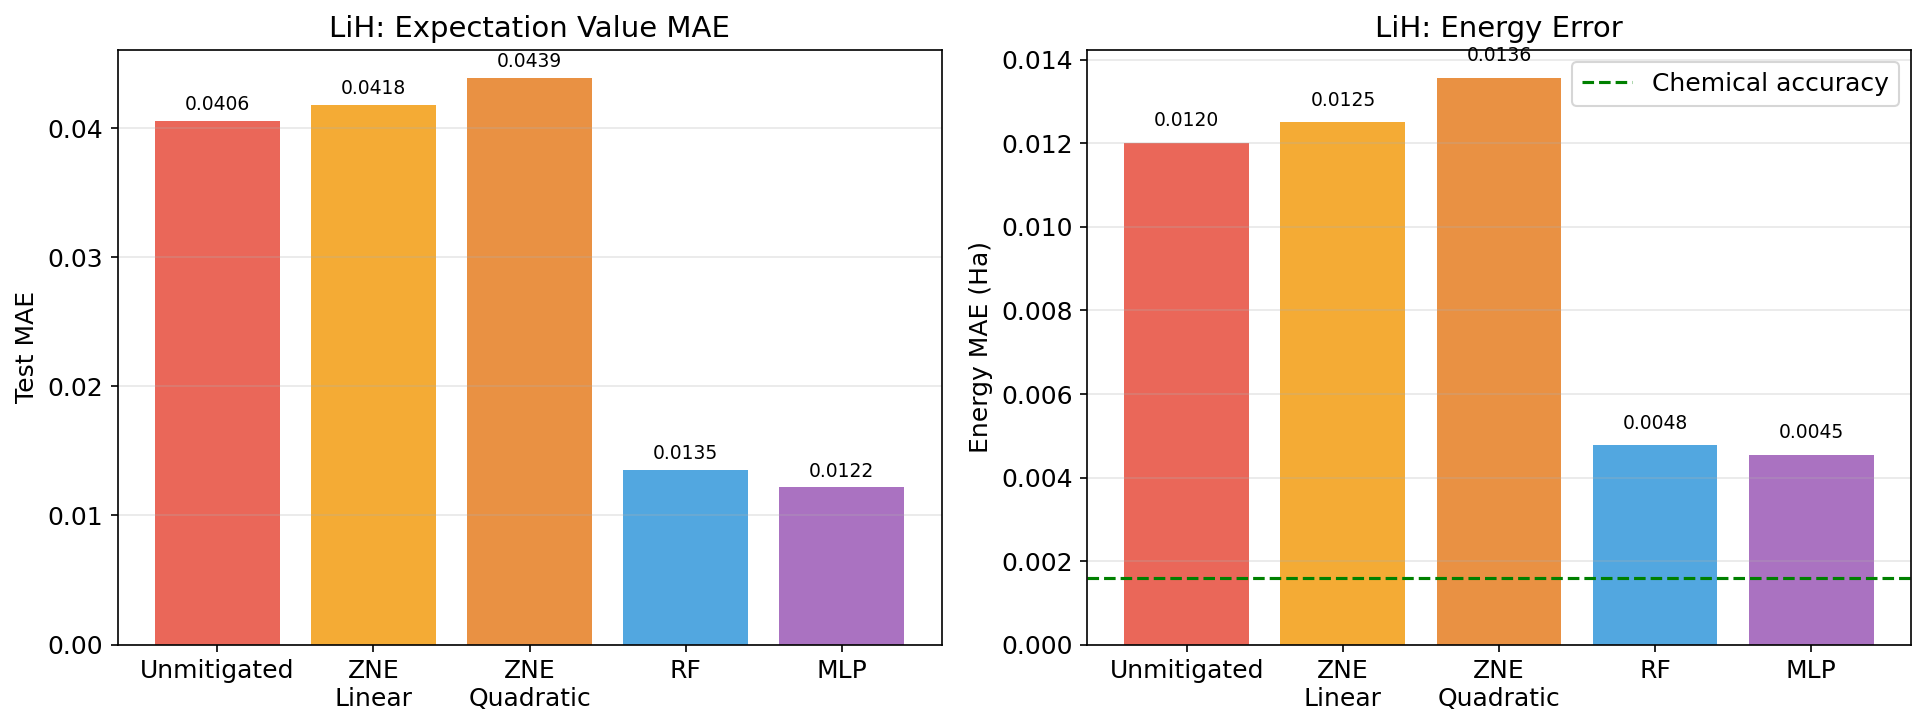

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
methods = ['Unmitigated', 'ZNE\nLinear', 'ZNE\nQuadratic', 'RF', 'MLP']
colors = ['#e74c3c', '#f39c12', '#e67e22', '#3498db', '#9b59b6']

ax = axes[0]
maes = [unmit_mae, zne_lin_mae, zne_quad_mae, rf_mae, mlp_mae]
bars = ax.bar(methods, maes, color=colors, alpha=0.85)
for bar, val in zip(bars, maes):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0005,
            f'{val:.4f}', ha='center', va='bottom', fontsize=9)
ax.set_ylabel('Test MAE'); ax.set_title('LiH: Expectation Value MAE'); ax.grid(axis='y', alpha=0.3)

ax = axes[1]
e_maes = [mean_absolute_error(E_ideal, E) for E in [E_unm, E_zl, E_zq, E_rf, E_mlp]]
bars = ax.bar(methods, e_maes, color=colors, alpha=0.85)
for bar, val in zip(bars, e_maes):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0003,
            f'{val:.4f}', ha='center', va='bottom', fontsize=9)
ax.axhline(0.0016, color='green', linestyle='--', linewidth=1.5, label='Chemical accuracy')
ax.set_ylabel('Energy MAE (Ha)'); ax.set_title('LiH: Energy Error'); ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('lih_zne_comparison.png', dpi=150, bbox_inches='tight')
plt.show()